# EDA Report - Automobile Dataset
By Sophie Glover

Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load the movies dataset
automobiles_df = pd.read_csv('automobile.txt')

### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [3]:
# dropping the columns 'normalized-losses' and 'symboling'

automobiles_df = automobiles_df.drop(['normalized-losses', 'symboling'], axis=1)

# display the first five rows

automobiles_df.head(5)

# info about the data set
automobiles_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               205 non-null    str    
 1   fuel-type          205 non-null    str    
 2   aspiration         205 non-null    str    
 3   num-of-doors       205 non-null    str    
 4   body-style         205 non-null    str    
 5   drive-wheels       205 non-null    str    
 6   engine-location    205 non-null    str    
 7   wheel-base         205 non-null    float64
 8   length             205 non-null    float64
 9   width              205 non-null    float64
 10  height             205 non-null    float64
 11  curb-weight        205 non-null    int64  
 12  engine-type        205 non-null    str    
 13  num-of-cylinders   205 non-null    str    
 14  engine-size        205 non-null    int64  
 15  fuel-system        205 non-null    str    
 16  bore               205 non-null    st

#### Remove any duplicate rows

In [4]:
# removing duplicate rows

automobiles_df.drop_duplicates()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [5]:
# remove rows with missing data

automobiles_df = automobiles_df.replace('?', np.nan)
automobiles_df = automobiles_df.dropna()

Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [6]:
# change numerical columns to integer data type

columns_int = ['horsepower', 'peak-rpm', 'price']
columns_float = ['bore', 'stroke']

automobiles_df[columns_int] = automobiles_df[columns_int].astype(np.int64)
automobiles_df[columns_float] = automobiles_df[columns_float].astype(np.float64)


### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [7]:
# Create a dataframe with all the cars in the "hatchback' category

hatchback_cars = automobiles_df[automobiles_df['body-style'] == 'hatchback']


### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

              make   body-style  price  city-mpg  highway-mpg
74   mercedes-benz      hardtop  45400        14           16
16             bmw        sedan  41315        16           22
73   mercedes-benz        sedan  40960        14           16
128        porsche  convertible  37028        17           25
17             bmw        sedan  36880        15           20


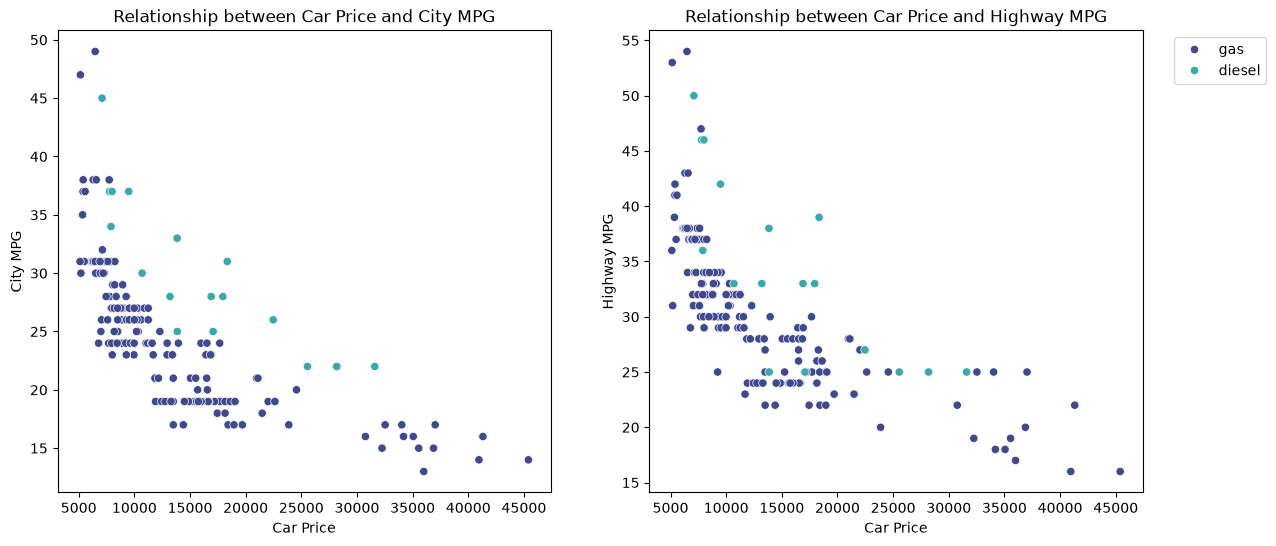

In [8]:
# five most expensive cars

top_five = automobiles_df.sort_values(by='price', ascending=False).head(5)

print(top_five[['make', 'body-style', 'price', 'city-mpg', 'highway-mpg']])


# create scatterplots investigating the relationship
# between car price and MPG

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.scatterplot(data=automobiles_df, x='price', y='city-mpg',
                     hue='fuel-type', palette='mako', ax=axes[0],
               legend=False)
axes[0].set(xlabel='Car Price', ylabel='City MPG')
axes[0].set_title("Relationship between Car Price and City MPG")


sns.scatterplot(data=automobiles_df, x='price', y='highway-mpg',
                     hue='fuel-type', palette='mako', ax=axes[1])
axes[1].set(xlabel='Car Price', ylabel='Highway MPG')
axes[1].set_title("Relationship between Car Price and Highway MPG")


axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

The top five most expensive cars are made by manufacturers Mercedes Benz, BMW and Porsche. Their prices range from 36880 to 45400, however both their city MPG and highway MPG are relatively low. The graphs showing the relationship between car price and city/highway MPG support this finding, as they show a negative correlation between the variables. As car price increases, MPG decreases in the city and on the highway, showing that top end buyers are prioritising luxury rather than efficiency. 

**Which manufacturer builds the most fuel efficient vehicles?**

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

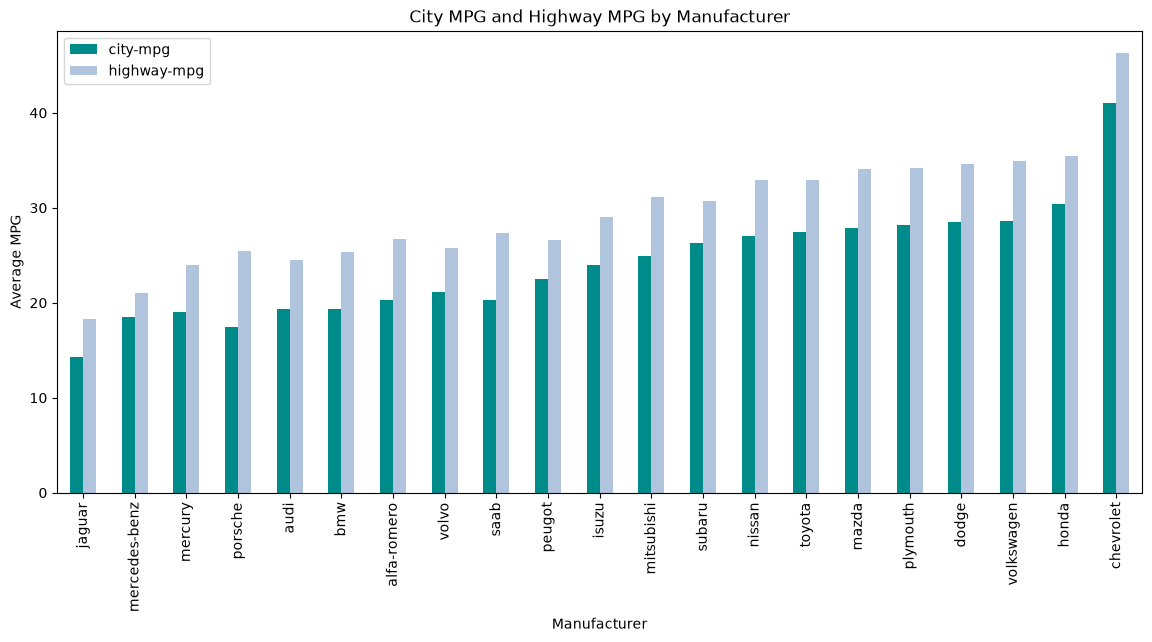

In [9]:
# average mpg by manufacturer on a bar plot

average = automobiles_df.groupby('make')[['city-mpg', 'highway-mpg']].mean()

average['overall_avmpg'] = (average['city-mpg'] +
                                 average['highway-mpg'])/2

arranged_data = average.sort_values(by='overall_avmpg')

arranged_data[['city-mpg', 'highway-mpg']].plot(kind='bar', 
                                                figsize=(14, 6),
                                               color=['darkcyan',
                                                      'lightsteelblue'])

plt.xlabel('Manufacturer')
plt.ylabel('Average MPG')
plt.title('City MPG and Highway MPG by Manufacturer')
plt.show()


The bar graph shows the average city MPG and the average highway MPG for each manufacturer's vehicles. The manufactureres with the most fuel efficient vehicles are Chevrolet, Honda and Volkswagen. 

#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

              make fuel-type aspiration num-of-doors   body-style  \
49          jaguar       gas        std          two        sedan   
73   mercedes-benz       gas        std         four        sedan   
74   mercedes-benz       gas        std          two      hardtop   
48          jaguar       gas        std         four        sedan   
47          jaguar       gas        std         four        sedan   
71   mercedes-benz       gas        std         four        sedan   
72   mercedes-benz       gas        std          two  convertible   
17             bmw       gas        std         four        sedan   
15             bmw       gas        std         four        sedan   
16             bmw       gas        std          two        sedan   
128        porsche       gas        std          two  convertible   
126        porsche       gas        std          two      hardtop   
127        porsche       gas        std          two      hardtop   
69   mercedes-benz    diesel      

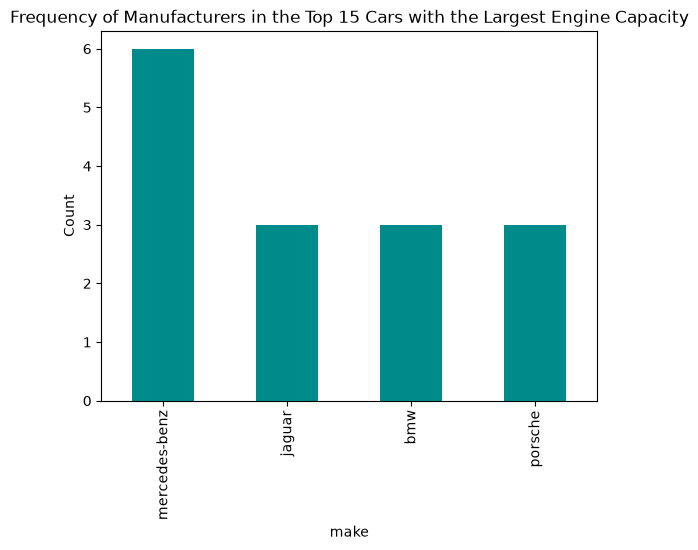

In [10]:
# bar chart showing the manufacturers whose cars have the largest engine capacity

largest_engines = automobiles_df.sort_values(by='engine-size', ascending=False)

top_15 = largest_engines.head(15)

print(top_15)

top_manufacturers = top_15['make'].value_counts()

top_manufacturers.plot(kind='bar', color='darkcyan')

plt.title('Frequency of Manufacturers in the Top 15 Cars with the Largest Engine Capacity')
plt.ylabel('Count')
plt.show()

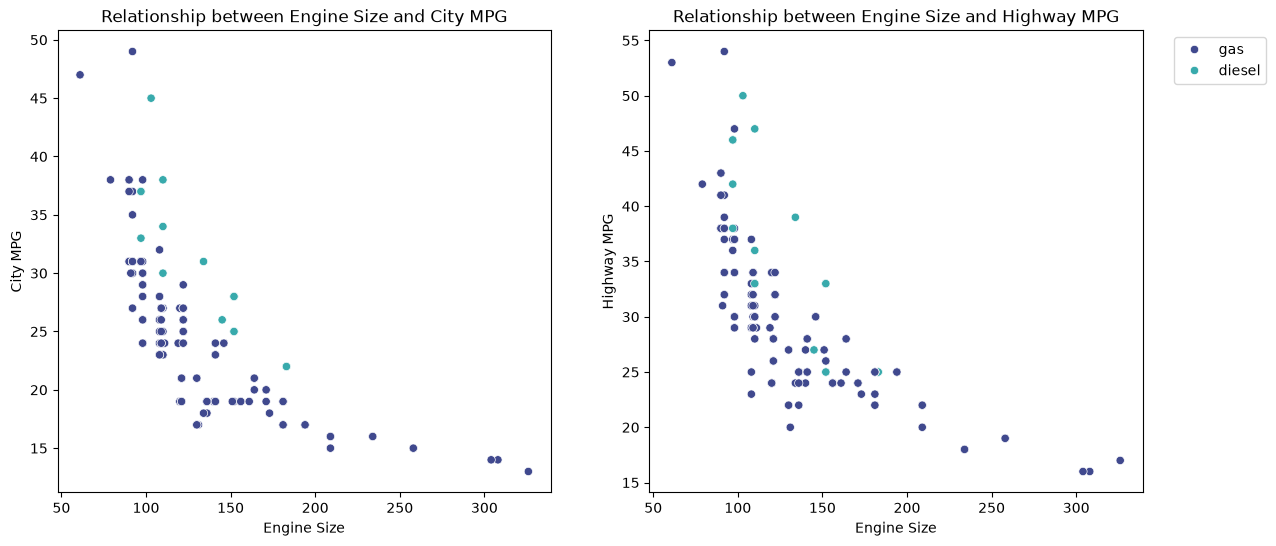

In [11]:
# investigating relationship between engine capacity and fuel efficiency

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=automobiles_df, x='engine-size', y='city-mpg',
                     hue='fuel-type', palette='mako', ax=axes[0],
               legend=False)
axes[0].set(xlabel='Engine Size', ylabel='City MPG')
axes[0].set_title("Relationship between Engine Size and City MPG")


sns.scatterplot(data=automobiles_df, x='engine-size', y='highway-mpg',
                     hue='fuel-type', palette='mako', ax=axes[1])
axes[1].set(xlabel='Engine Size', ylabel='Highway MPG')
axes[1].set_title("Relationship between Engine Size and Highway MPG")


axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Amongst the top 15 vehicles with the largest engine capacities, 6 of them are made by manufacturer Mercedes Benz. The other 9 are evenly divided between Jaguar, BMW and Porsche. These manufacturers also appeared amongst the lowest for their vehicles fuel efficiency. Upon further investigation, it can be seen from the graph that the larger the engine, the lower the MPG.

#### Which vehicle manufacturer has the most car models in the dataset

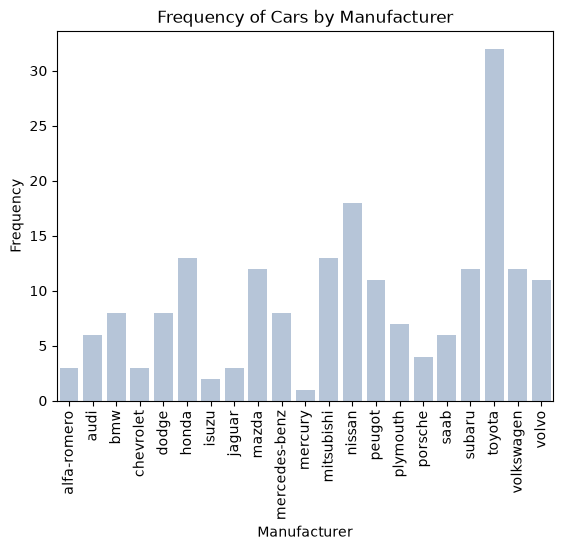

In [12]:
# bar chart to show the frequency for each manufacturer

fg = sns.countplot(data=automobiles_df, x='make',
                   color='lightsteelblue')

plt.xticks(rotation=90)

plt.title('Frequency of Cars by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Frequency')
plt.show()


The bar graph shows that the manufacturer with the most car models in the dataset is Toyota, followed by Nissan. This might be due to the more affordable nature of these cars.